# Hello World R Notebook

This notebook demonstrates a working R environment in a dev container with Jupyter notebook support. It includes all the requested R packages and shows basic functionality.

## 1. Basic R Hello World

Let's start with a simple "Hello World" in R and check our R version.

In [1]:
# Basic Hello World
print("Hello World from R!")

# Check R version
R.version.string

# Get current date and time
Sys.time()

[1] "Hello World from R!"


[1] "R version 4.3.3 (2024-02-29)"

[1] "2025-10-01 01:29:42 UTC"

## 2. Test Installed Packages

Let's verify that all the requested R packages are properly installed and can be loaded.

In [2]:
# Load and test the requested packages
packages_to_test <- c("devtools", "ggplot2", "vegan", "ggpubr", "taxonomizr", "stringr")

cat("Testing package installation:\n")
for (pkg in packages_to_test) {
  if (require(pkg, character.only = TRUE, quietly = TRUE)) {
    cat("✓", pkg, "loaded successfully\n")
  } else {
    cat("✗", pkg, "failed to load\n")
  }
}

# Show versions of key packages
cat("\nPackage versions:\n")
cat("ggplot2 version:", as.character(packageVersion("ggplot2")), "\n")
cat("stringr version:", as.character(packageVersion("stringr")), "\n")

Testing package installation:
✓ devtools loaded successfully
✓ ggplot2 loaded successfully



Attaching package: ‘permute’


The following object is masked from ‘package:devtools’:

    check




✓ vegan loaded successfully
✓ ggpubr loaded successfully
✓ taxonomizr loaded successfully
✓ stringr loaded successfully

Package versions:
ggplot2 version: 3.5.2 
stringr version: 1.5.2 


## 3. Basic Data Manipulation

Let's create some sample data and demonstrate basic R functionality with stringr.

In [3]:
# Create sample data
sample_data <- data.frame(
  species = c("Escherichia coli", "Bacillus subtilis", "Staphylococcus aureus", "Pseudomonas aeruginosa"),
  count = c(150, 89, 234, 67),
  temperature = c(37, 30, 37, 28)
)

print("Sample microbiology data:")
print(sample_data)

# String manipulation with stringr
library(stringr)
sample_data$genus <- str_extract(sample_data$species, "^[A-Z][a-z]+")
sample_data$species_short <- str_c(str_sub(sample_data$genus, 1, 1), ". ",
                                   str_extract(sample_data$species, " [a-z]+$"))

print("\nData with extracted genus and short species names:")
print(sample_data[, c("species", "genus", "species_short", "count")])

[1] "Sample microbiology data:"
                 species count temperature
1       Escherichia coli   150          37
2      Bacillus subtilis    89          30
3  Staphylococcus aureus   234          37
4 Pseudomonas aeruginosa    67          28
[1] "\nData with extracted genus and short species names:"
                 species          genus  species_short count
1       Escherichia coli    Escherichia       E.  coli   150
2      Bacillus subtilis       Bacillus   B.  subtilis    89
3  Staphylococcus aureus Staphylococcus     S.  aureus   234
4 Pseudomonas aeruginosa    Pseudomonas P.  aeruginosa    67


## 4. Data Visualization with ggplot2

Let's create some basic visualizations to demonstrate that ggplot2 is working correctly.

`geom_smooth()` using formula = 'y ~ x'


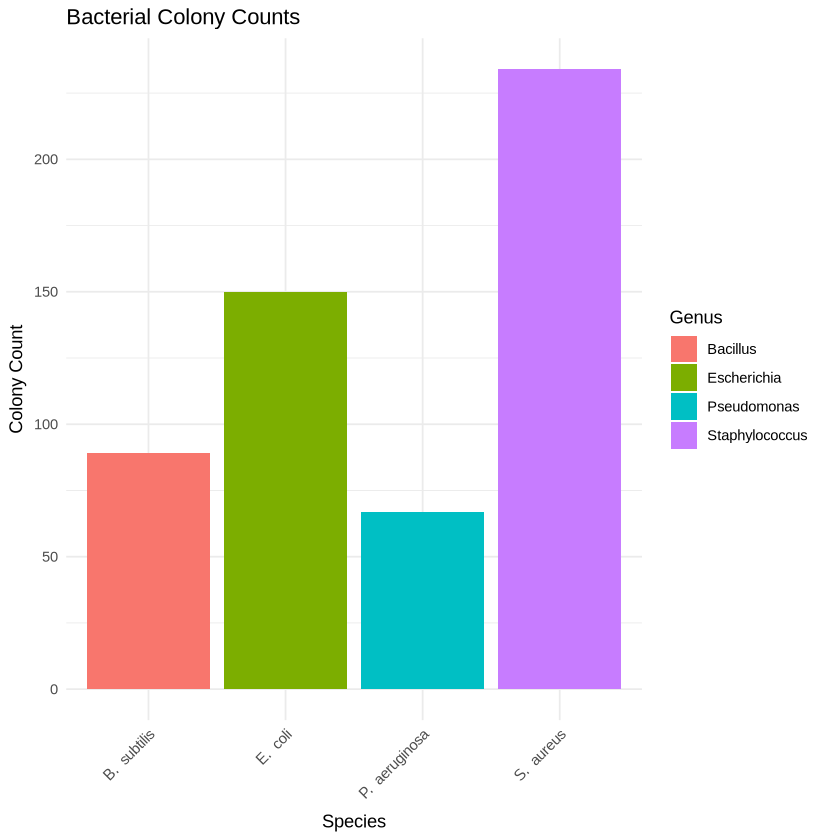

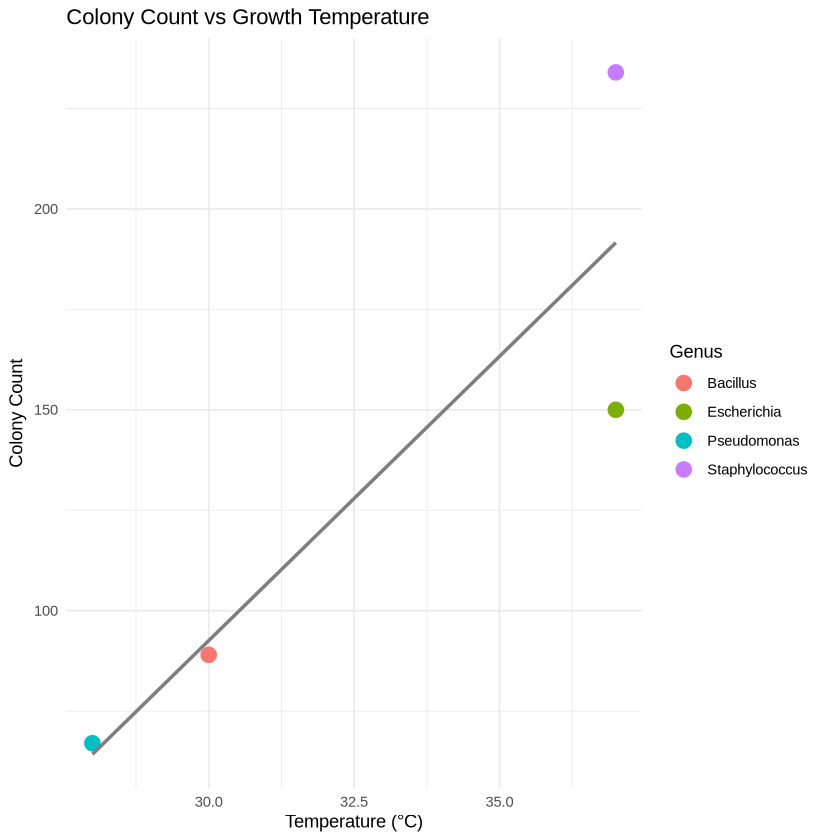

In [4]:
# Load ggplot2
library(ggplot2)

# Create a bar plot of bacterial counts
p1 <- ggplot(sample_data, aes(x = species_short, y = count, fill = genus)) +
  geom_col() +
  labs(title = "Bacterial Colony Counts",
       x = "Species",
       y = "Colony Count",
       fill = "Genus") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

print(p1)

# Create a scatter plot of count vs temperature
p2 <- ggplot(sample_data, aes(x = temperature, y = count, color = genus)) +
  geom_point(size = 4) +
  geom_smooth(method = "lm", se = FALSE, color = "gray50") +
  labs(title = "Colony Count vs Growth Temperature",
       x = "Temperature (°C)",
       y = "Colony Count",
       color = "Genus") +
  theme_minimal()

print(p2)